# 신용카드 사기검출 — Stage5(SMOTE) + 임계값 0.04, 5개 모델 최종 비교

담당: 정찬성 | 기준: log1p(Amount) + V14 이상치(IQR) 제거 + SMOTE(학습데이터만) 전처리 위에서, 분류 임계값을 0.5가 아닌 **0.04**로 낮췄을 때 5개 모델(XGBoost/LogisticRegression/LightGBM/RandomForest/GradientBoost)의 성능을 비교한다.

이 노트북은 최종 비교표 한 장 + 모델별 그래프 5장만 출력하도록, 중간 진단·단계별 비교표는 모두 제거하고 핵심 파이프라인만 남겼다.

```mermaid
flowchart TD
    A[creditcard.csv 로드] --> B[Amount log1p 변환 + Time 제거]
    B --> C[V14 이상치 IQR 1.5배 제거]
    C --> D[학습/검증 분할 Stratified 7:3]
    D --> E[SMOTE 오버샘플링 학습데이터만]
    E --> F["5개 모델 학습<br/>XGBoost / LogisticRegression / LightGBM / RandomForest / GradientBoost"]
    F --> G[임계값 0.04 적용 평가]
    G --> H[5모델 비교표 1개 출력]
    G --> I[모델별 정규화 혼동행렬 5장]
```


In [1]:
import numpy as np
import pandas as pd
import warnings
import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Binarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

_start_time = datetime.datetime.now()
print(f'[전체 실행 시작] {_start_time}')


[전체 실행 시작] 2026-08-28 18:07:12.682398


In [2]:
print(f'[1. 데이터 로드 + 전처리 시작] {datetime.datetime.now()}')
# Amount는 오른쪽 꼬리가 긴 분포라 log1p로 압축, Time은 사기 여부와 인과관계가 없어 제거
card_df = pd.read_csv('../data/creditcard.csv')
df = card_df.copy()
df.insert(0, 'Amount_Scaled', np.log1p(df['Amount']))
df = df.drop(columns=['Time', 'Amount'])

# 사기(Class=1) 표본 안에서만 V14 이상치를 IQR 1.5배 기준으로 제거(정상 표본은 건드리지 않음)
fraud_v14 = df[df['Class'] == 1]['V14']
q25, q75 = np.percentile(fraud_v14, 25), np.percentile(fraud_v14, 75)
iqr_gap = (q75 - q25) * 1.5
outlier_idx = fraud_v14[(fraud_v14 < q25 - iqr_gap) | (fraud_v14 > q75 + iqr_gap)].index
df = df.drop(index=outlier_idx)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]


[1. 데이터 로드 + 전처리 시작] 2026-08-28 18:07:12.692070


In [3]:
print(f'[2. 학습/검증 분할 + SMOTE 시작] {datetime.datetime.now()}')
# 사기 비율이 0.17%뿐이라 stratify로 분할, SMOTE는 반드시 학습 데이터에만 적용(검증셋은 원본 분포 유지)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
X_train_over, y_train_over = SMOTE(random_state=0).fit_resample(X_train, y_train)


[2. 학습/검증 분할 + SMOTE 시작] 2026-08-28 18:07:14.623817


In [4]:
print(f'[3. XGBoost 학습 시작] {datetime.datetime.now()}')
xgb_clf = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05,
                         n_jobs=-1, random_state=156, eval_metric='logloss')
xgb_clf.fit(X_train_over, y_train_over);


[3. XGBoost 학습 시작] 2026-08-28 18:07:16.529515


In [5]:
print(f'[4. LogisticRegression 학습 시작] {datetime.datetime.now()}')
lr_clf = LogisticRegression(max_iter=1000, random_state=156)
lr_clf.fit(X_train_over, y_train_over);


[4. LogisticRegression 학습 시작] 2026-08-28 18:07:25.138445


In [6]:
print(f'[5. LightGBM 학습 시작] {datetime.datetime.now()}')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1,
                           boost_from_average=False, random_state=156, verbose=-1)
lgbm_clf.fit(X_train_over, y_train_over);


[5. LightGBM 학습 시작] 2026-08-28 18:07:26.674904


In [7]:
print(f'[6. RandomForest 학습 시작] {datetime.datetime.now()}')
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
rf_clf.fit(X_train_over, y_train_over);


[6. RandomForest 학습 시작] 2026-08-28 18:07:39.422119


In [8]:
print(f'[7. GradientBoost 학습 시작] {datetime.datetime.now()}')
# 레거시 GradientBoostingClassifier는 단일 코어 + 비히스토그램 방식이라 대용량에서 비현실적으로 느려,
# 같은 그래디언트 부스팅 계열이면서 히스토그램 기반으로 훨씬 빠른 HistGradientBoostingClassifier를 쓴다.
gb_clf = HistGradientBoostingClassifier(max_iter=1000, max_depth=3, learning_rate=0.05,
                                         early_stopping=True, n_iter_no_change=20, validation_fraction=0.1,
                                         random_state=156)
gb_clf.fit(X_train_over, y_train_over);


[7. GradientBoost 학습 시작] 2026-08-28 18:14:00.006734


In [9]:
print(f'[8. 임계값 0.04 평가 시작] {datetime.datetime.now()}')
THRESHOLD = 0.04

def evaluate(model, X, y, thr):
    proba = model.predict_proba(X)[:, 1]
    pred = Binarizer(threshold=thr).fit_transform(proba.reshape(-1, 1)).ravel()
    return {
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
        'auc': roc_auc_score(y, proba),
    }

models = {
    'XGBoost': xgb_clf,
    '로지스틱 회귀': lr_clf,
    'LightGBM': lgbm_clf,
    '랜덤포레스트': rf_clf,
    'GradientBoost': gb_clf,
}

result_df = pd.DataFrame(
    [{'모델': name, **evaluate(model, X_test, y_test, THRESHOLD)} for name, model in models.items()]
)

_end_time = datetime.datetime.now()
print(f'[전체 실행 종료] {_end_time}')
print(f'[총 소요시간] {_end_time - _start_time}')
print()
print(f'=== Stage 5(SMOTE) + 임계값 {THRESHOLD} — 5개 모델 비교 ===')
print(result_df.to_string(index=False))


[8. 임계값 0.04 평가 시작] 2026-08-28 18:14:19.723778


[전체 실행 종료] 2026-08-28 18:14:23.174318
[총 소요시간] 0:07:10.491920

=== Stage 5(SMOTE) + 임계값 0.04 — 5개 모델 비교 ===
           모델  accuracy  precision   recall       f1      auc
      XGBoost  0.972624   0.054449 0.917808 0.102800 0.984773
      로지스틱 회귀  0.632647   0.004504 0.972603 0.008967 0.973641
     LightGBM  0.999391   0.801282 0.856164 0.827815 0.982904
       랜덤포레스트  0.987360   0.112126 0.924658 0.200000 0.988381
GradientBoost  0.973526   0.056580 0.924658 0.106635 0.984490


## 5개 모델 — 정규화 혼동행렬(Confusion Matrix, 임계값 0.04)

사기 비율이 0.17%뿐이라 원본 건수로 그리면 정상 거래 칸이 색을 독차지해 사기 탐지 결과가 안 보인다. 행 기준으로 정규화(`normalize='true'`)해 "실제 정상/사기 중 몇 %를 맞혔는지"를 한 번에 보이게 한 것이 가장 단순하고 이해하기 쉬운 형태다.

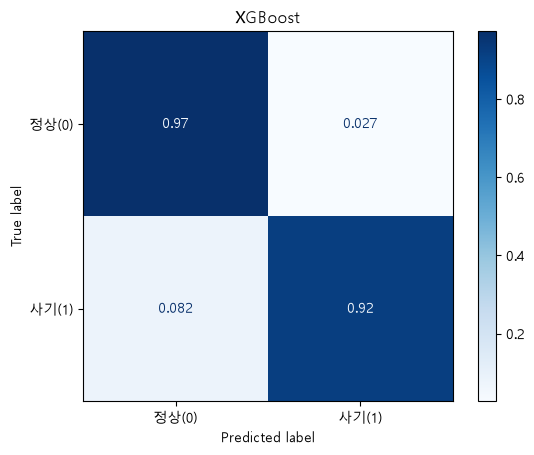

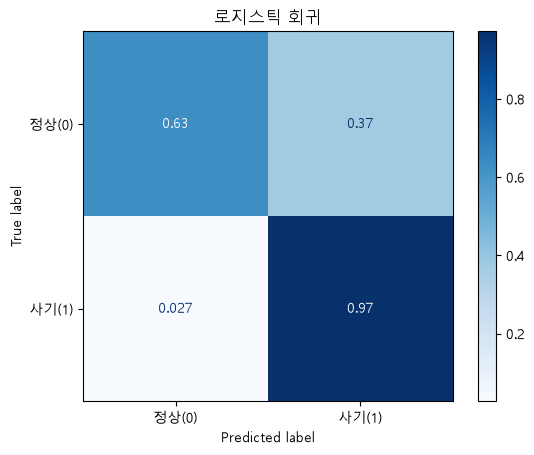

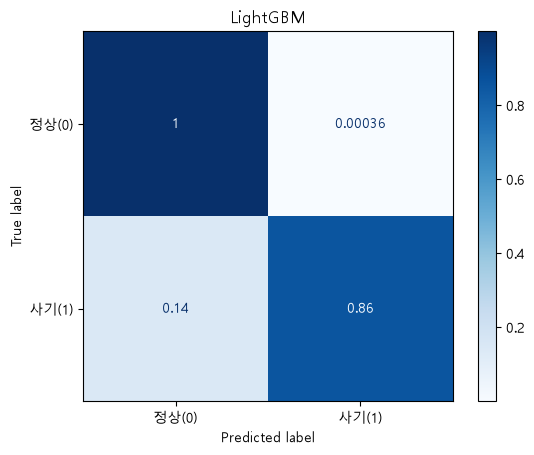

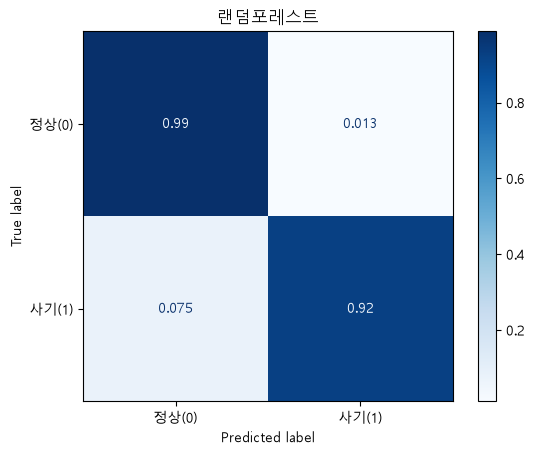

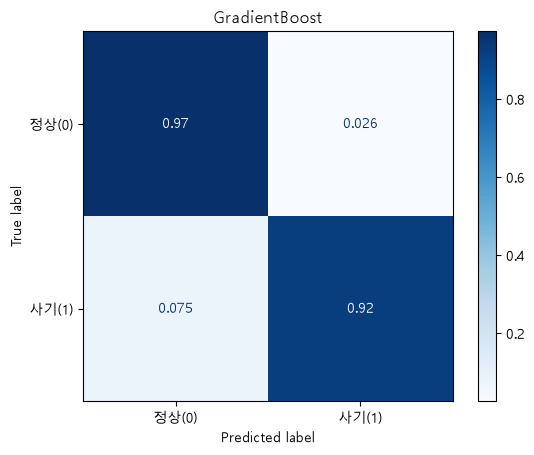

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = Binarizer(threshold=THRESHOLD).fit_transform(proba.reshape(-1, 1)).ravel()
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, normalize='true', display_labels=['정상(0)', '사기(1)'], cmap='Blues'
    )
    plt.title(name)
    plt.show()
